In [1]:
# importaçaoes
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# carregando dados 
balance_path = os.path.join('..','data', 'processed', 'balance.csv')
bureau_path = os.path.join('..','data', 'processed', 'bureau.csv')
customer_path = os.path.join('..','data', 'processed', 'customers_hist.csv')
df_balance = pd.read_csv(balance_path)
df_bureau = pd.read_csv(bureau_path)
df_customers = pd.read_csv(customer_path)

In [36]:
#funçoes auxiliares
class plot_groupby():
    def __init__(self, data:pd.DataFrame, col1:str, col2:str, title:str):
        """"title: na média estara, por exemplo, média entre ....", voce completa"""
        self.data = data
        self.col1 = col1
        self.col2 = col2
        self.title = title
    def plot_mean(self):
        group = self.data.groupby(self.col1)[self.col2].mean()
        
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,10))
        axes[0].set_title(f'Média entre {self.title}')
        sns.barplot(group, palette='pastel', ax=axes[0])
        axes[0].tick_params(axis='x', rotation=90)

        
        
        group2 = self.data.groupby(self.col1)[self.col2].sum()
        axes[1].set_title(f'Valores totais {self.title}')
        sns.barplot(group2, palette='pastel', ax=axes[1])
        axes[1].tick_params(axis='x', rotation=90)

        fig.tight_layout()
        fig.show()
# funcao para plot de grafico hue
def hue_plot(data: pd.DataFrame,col1:str,col2:str, hue:str, title:str):
    try:
        plt.figure(figsize=(20,10))
        plt.title(f'{title}')
        sns.barplot(data=data, x=col1, y=col2,  hue=hue, palette='pastel')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    except ValueError as e:
        return {f'{e}'}


# Bureau Balance

In [5]:
df_balance.groupby('MONTHS_BALANCE')['STATUS']

In [6]:
#verificando dados nulos 
df_balance.isnull().sum()

SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [7]:
df_balance['STATUS'].value_counts()

STATUS
C    7238
X    4063
0    3604
1      83
2      10
3       2
Name: count, dtype: int64

In [8]:
# verificando id's repetidos 
df_balance['SK_ID_BUREAU'].duplicated().value_counts()

SK_ID_BUREAU
True     14622
False      378
Name: count, dtype: int64

In [9]:
# aplicando multiplicaçao por -1 para tirar fator negativo nos atrasos 
df_balance['MONTHS_BALANCE'] = df_balance['MONTHS_BALANCE']*-1

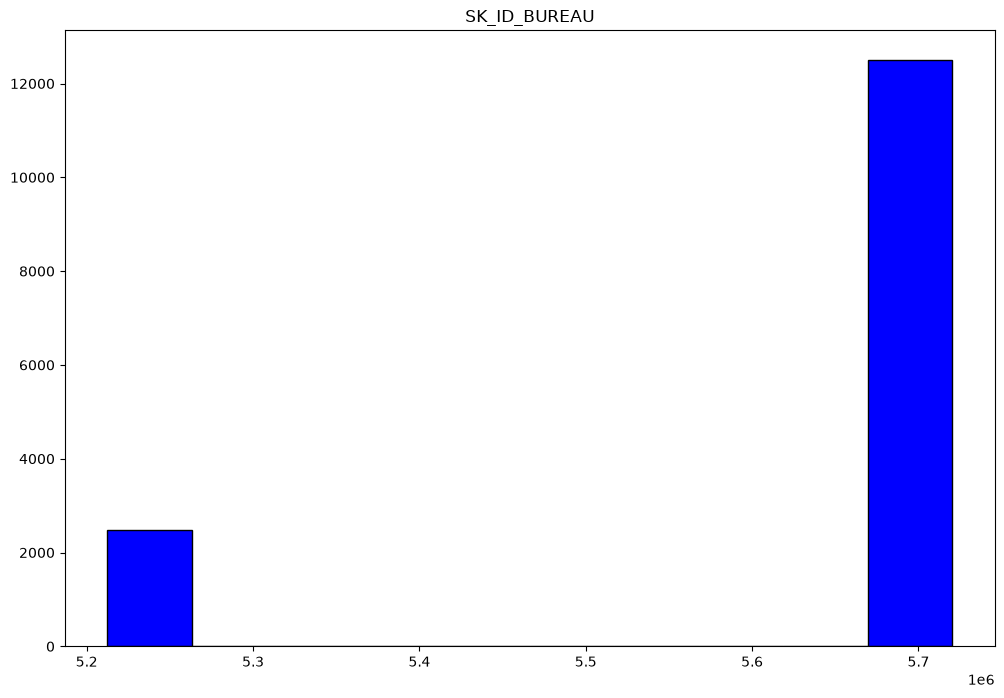

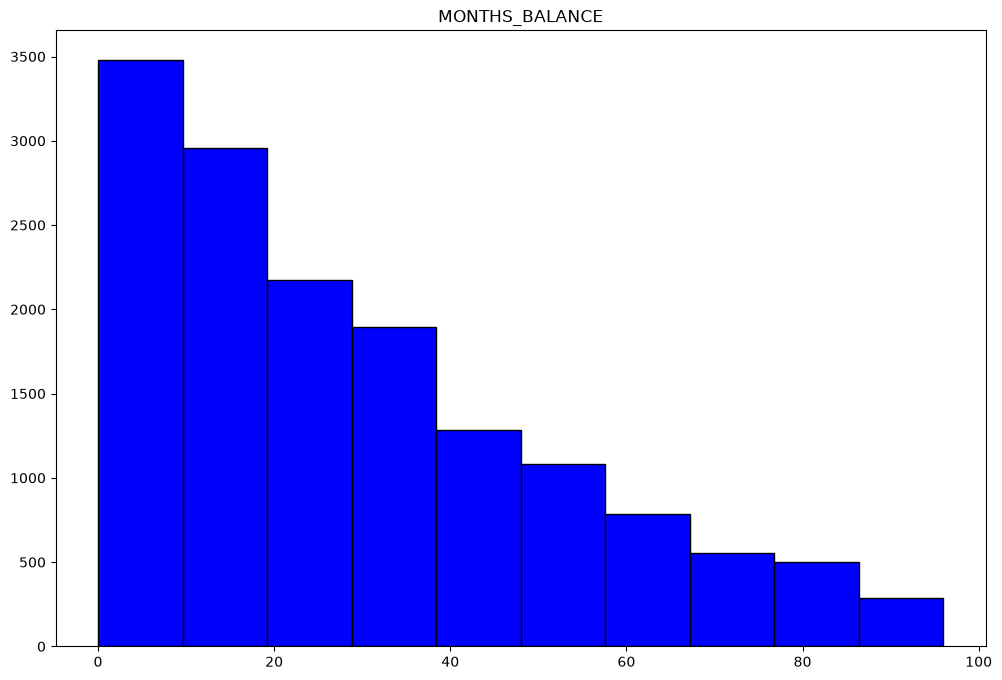

In [10]:
num_col_balance = df_balance.select_dtypes(include='number')
for num_bal in num_col_balance:
    plt.figure(figsize=(12,8))
    plt.title(f'{num_bal}')
    plt.hist(df_balance[num_bal], color='blue', edgecolor='black')
    plt.show()

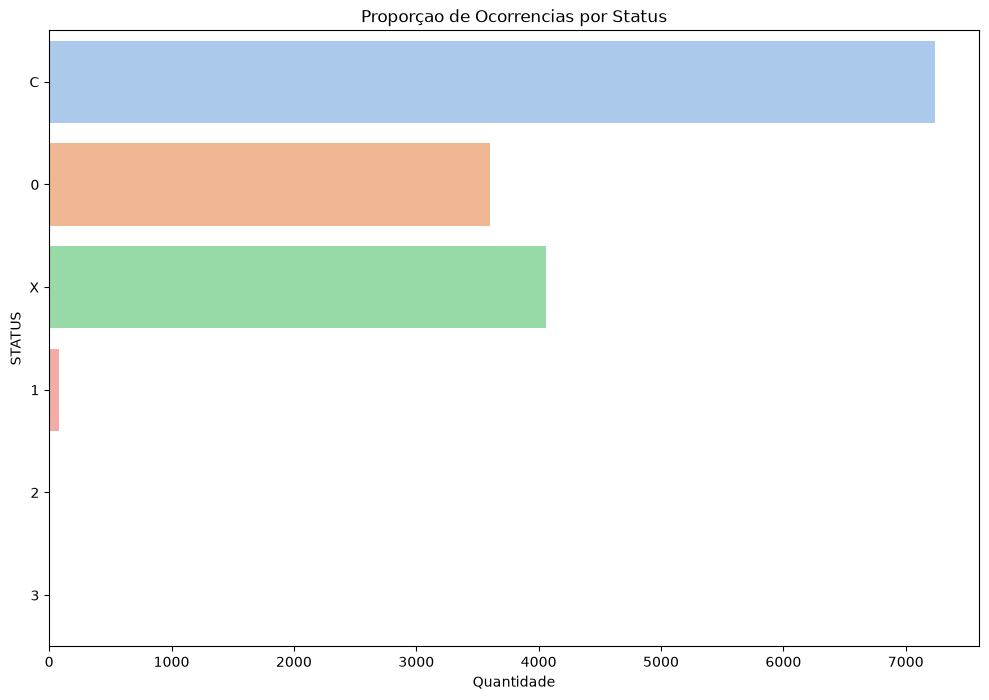

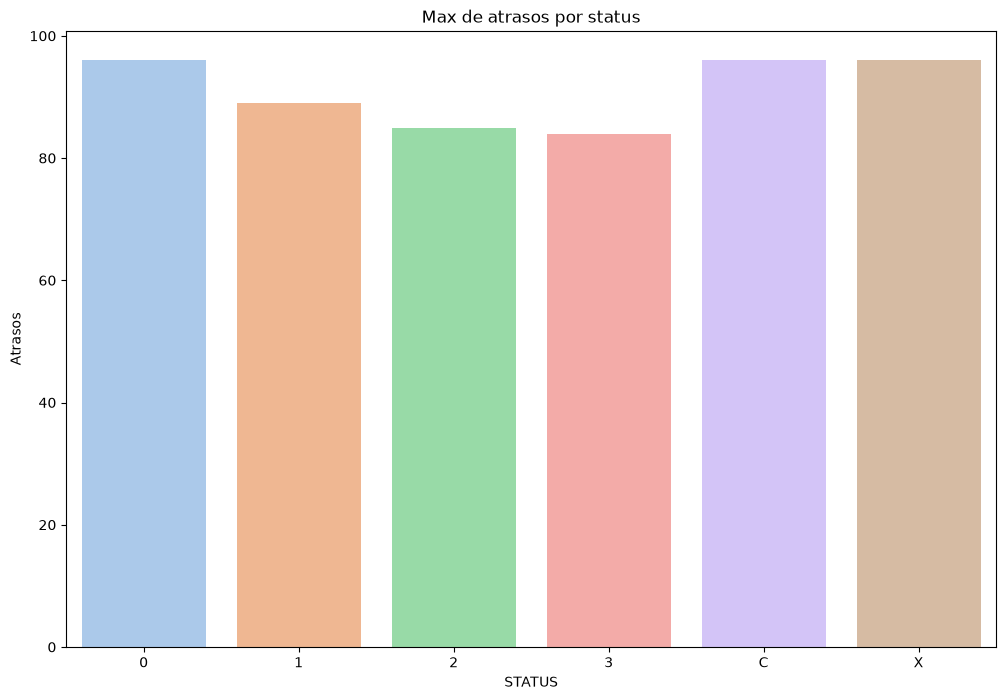

In [11]:
# filtrando id's com maior atraso e avaliando reputaçao 
filter = df_balance.groupby('STATUS')[['MONTHS_BALANCE']].max()

# plotando quantidade de ocorrencias por status
plt.figure(figsize=(12,8))
plt.title('Proporçao de Ocorrencias por Status')
sns.countplot(data=df_balance, y='STATUS', palette='pastel')
plt.xlabel('Quantidade')
plt.show()

# plotando filtro de maiores atrasos por status 
plt.figure(figsize=(12,8))
plt.title('Max de atrasos por status')
sns.barplot(data=filter, x='STATUS', y='MONTHS_BALANCE', palette='pastel')
plt.ylabel('Atrasos')
plt.show()


# Bureau 

In [12]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


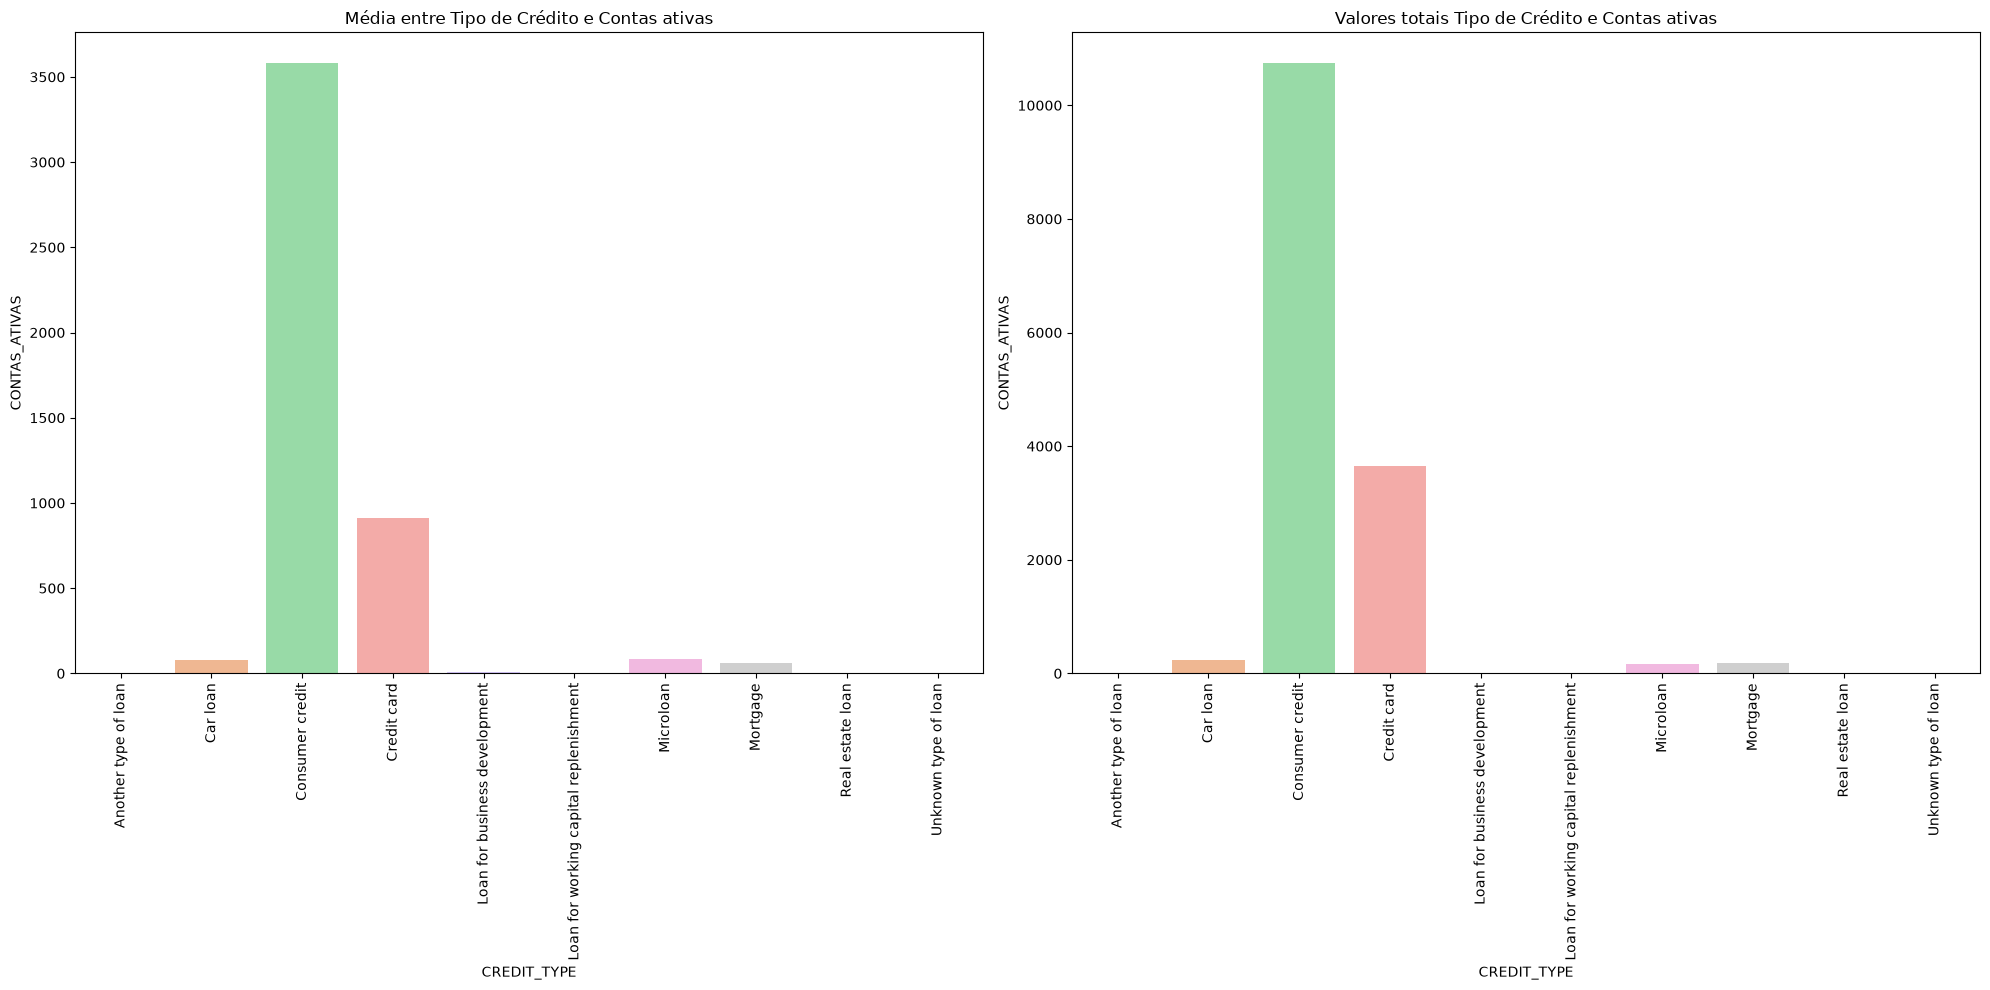

In [13]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'CONTAS_ATIVAS', 'Tipo de Crédito e Contas ativas').plot_mean()

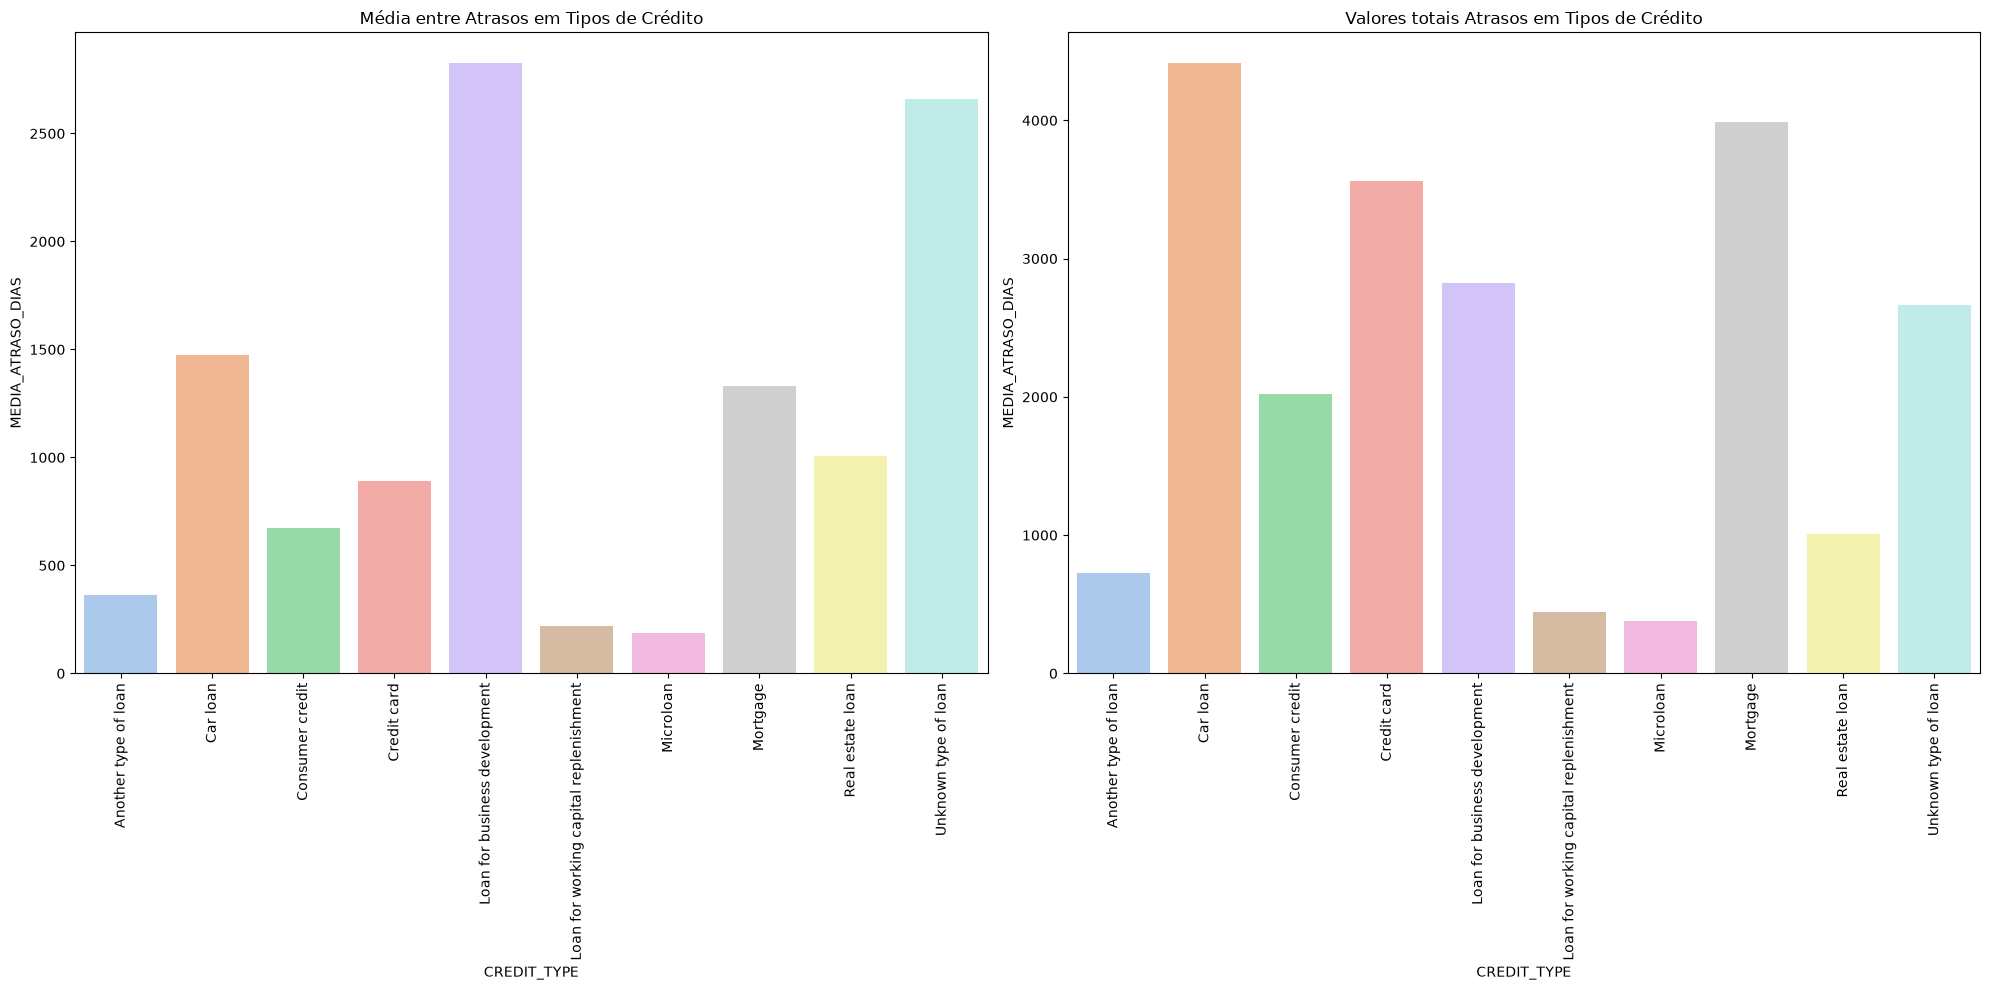

In [14]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'Atrasos em Tipos de Crédito').plot_mean()

In [16]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


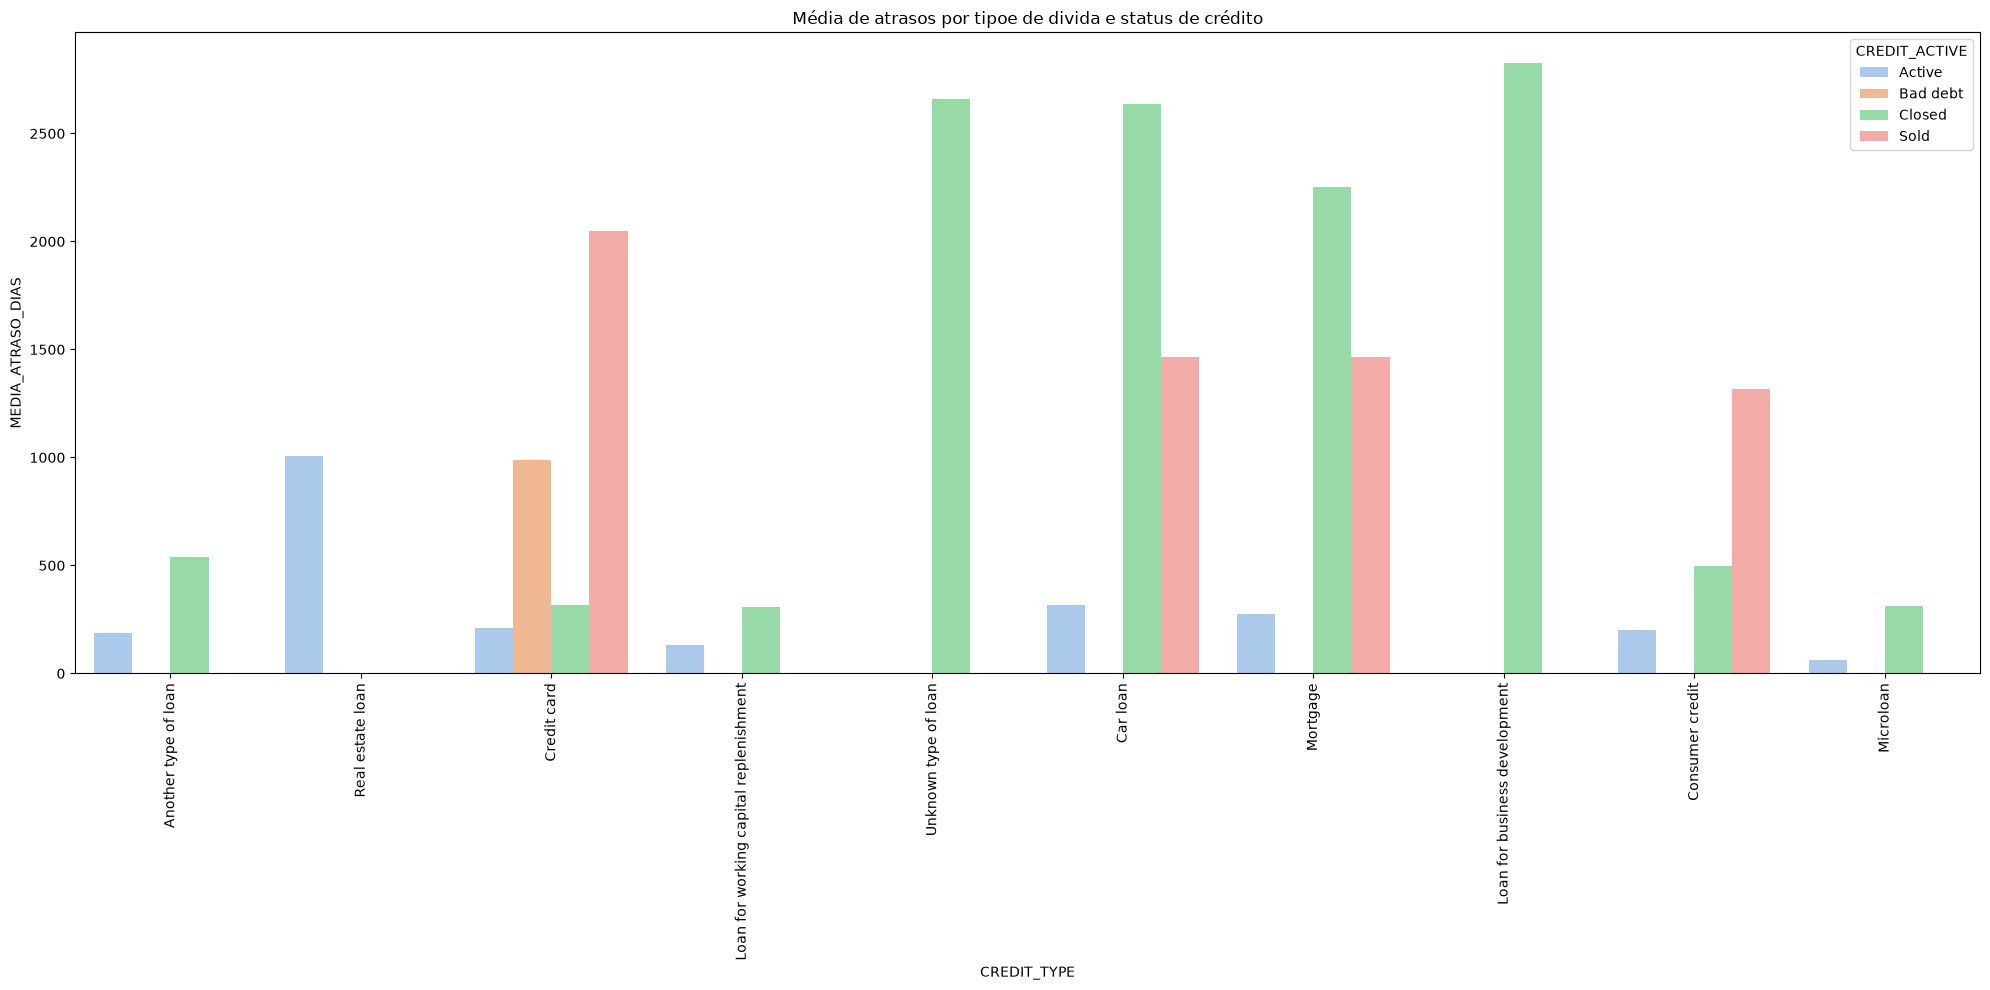

In [37]:
# plotar graficos Hue
hue_plot(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'CREDIT_ACTIVE', 'Média de atrasos por tipoe de divida e status de crédito')